# Genome Tracks Tutorial

This tutorial introduces the **geneview.genometracks** module — a Gviz-inspired
genome track visualization system for Python. You will learn how to create and
combine different track types to produce publication-quality genomic figures.

**Track types covered:**
- `GenomeAxisTrack` — genomic coordinate axis (with direction indicators)
- `AnnotationTrack` — BED annotation features (box, ellipse, arrow, fixedArrow, smallArrow)
- `GeneRegionTrack` — gene models from GTF/GFF (exons, UTRs, introns; collapse modes including meta)
- `DataTrack` — numeric data (line, histogram, heatmap, polygon, points, mountain, gradient, combined, stairs)
- `HighlightTrack` — cross-track highlight regions (per-region colors)
- `OverlayTrack` — overlay multiple tracks on the same axes

**Additional features:** transformation, windowing/smoothing, aggregation, legend, grid, reverse strand, fractional extend.

> **Prerequisites:** Make sure you have run `generate_genome_tracks_data.py` to
> create the example data files used in this tutorial.

## Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geneview.genometracks import (
    GenomeAxisTrack, AnnotationTrack, GeneRegionTrack, DataTrack,
    HighlightTrack, OverlayTrack, GenomicInterval, plot_tracks,
    read_bed, read_gff, read_bedgraph,
)

### Locate example data

All data files live in `examples/data/genome_tracks/` (relative to the
geneview repository root). We use a relative path from this notebook:

In [2]:
DATA_DIR = "../../examples/data/genome_tracks"
BED_FILE      = f"{DATA_DIR}/cpg_islands.bed"
GTF_FILE      = f"{DATA_DIR}/gene_models.gtf"
BEDGRAPH_FILE = f"{DATA_DIR}/coverage.bedgraph"
ANN_FILE      = f"{DATA_DIR}/annotations.bed"


### Define the genomic region of interest

All examples focus on a region of **chromosome 7** (26.5–26.8 Mb), which
contains several gene models and CpG islands in our synthetic dataset.

In [3]:
region = GenomicInterval("chr7", 26_500_000, 26_800_000)
print(f"Region: {region.chrom}:{region.start:,}–{region.end:,}")


Region: chr7:26,500,000–26,800,000


---
## 1. Basic Tracks — GenomeAxisTrack + AnnotationTrack

The simplest genome tracks plot combines:
1. A **GenomeAxisTrack** that shows the genomic coordinate scale
2. An **AnnotationTrack** that displays features from a BED file

The `plot_tracks()` function takes a list of tracks and a genomic region,
then renders everything into a vertically stacked figure using matplotlib
GridSpec.

### Load CpG island data from a BED file

In [4]:
cpg_data = read_bed(BED_FILE)
print(f"Loaded {len(cpg_data)} CpG island features")
cpg_data.head()


Loaded 9 CpG island features


,chrom,start,end,name,score,strand
0,chr7,26500100,26500800,CpG_1,0,+
1,chr7,26520000,26520500,CpG_2,0,+
2,chr7,26560200,26560900,CpG_3,0,-
3,chr7,26580000,26580350,CpG_4,0,+
4,chr7,26610500,26611200,CpG_5,0,-


### Create tracks and plot

- `AnnotationTrack` accepts a DataFrame and a `stacking` mode (`"squish"`,
  `"pack"`, `"dense"`, `"full"`, or `"hide"`).
- `GenomeAxisTrack()` creates a coordinate axis automatically sized to the
  displayed region.

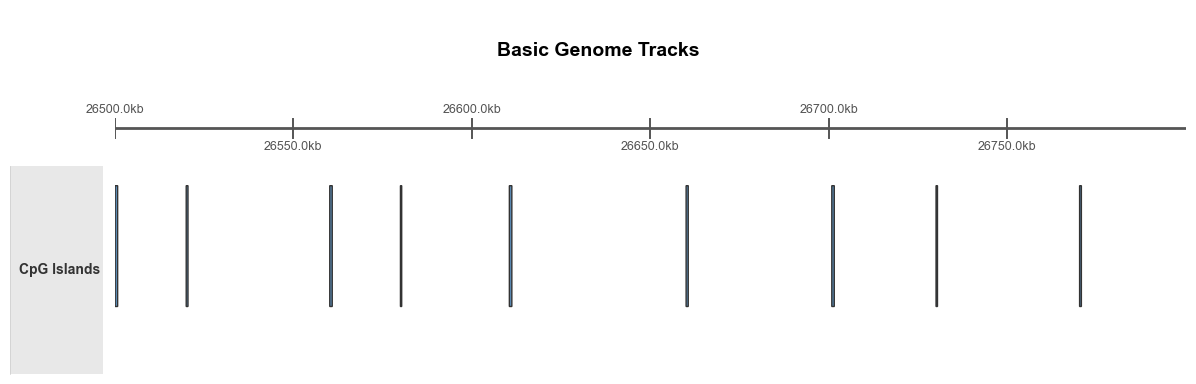

In [5]:
gtrack = GenomeAxisTrack()
atrack = AnnotationTrack(cpg_data, name="CpG Islands", stacking="squish")

axes = plot_tracks(
    [gtrack, atrack],
    region=region,
    title="Basic Genome Tracks",
    figsize=(12, 4),
)
plt.show()


> **Note:** `plot_tracks()` returns a list of matplotlib `Axes` objects
> (one per track panel). To access the figure, use `axes[0].figure`.

---
## 2. GeneRegionTrack — Visualize Gene Models

`GeneRegionTrack` renders gene structures from GTF/GFF files, showing
exons, UTRs, CDS regions, and intron connections. It supports three
transcript collapsing modes via `collapse_transcripts`:

| Mode | Description |
|------|-------------|
| `None` (default) | Show all individual transcripts |
| `"gene"` | Collapse all transcripts into a single gene-level model |
| `"longest"` | Show only the longest transcript per gene |

### Load gene model data from GTF

In [6]:
gene_data = read_gff(GTF_FILE)
print(f"Loaded {len(gene_data)} gene model features")
gene_data.head()


Loaded 34 gene model features


,chrom,source,feature,start,end,score,strand,frame,gene_id,transcript_id,exon_number,gene_name
0,chr7,geneview,+,26500499,26500800,.,+,.,ENSG00001,ENST00001a,1,BRCA_L1
1,chr7,geneview,+,26500499,26500650,.,+,.,ENSG00001,ENST00001a,1,BRCA_L1
2,chr7,geneview,+,26500650,26500800,.,+,.,ENSG00001,ENST00001a,1,BRCA_L1
3,chr7,geneview,+,26509999,26510400,.,+,.,ENSG00001,ENST00001a,2,BRCA_L1
4,chr7,geneview,+,26509999,26510400,.,+,.,ENSG00001,ENST00001a,2,BRCA_L1


In [7]:
# Slightly wider region to capture full gene extents
gene_region = GenomicInterval("chr7", 26_490_000, 26_720_000)
gtrack = GenomeAxisTrack()


### 2a. All transcripts (default)

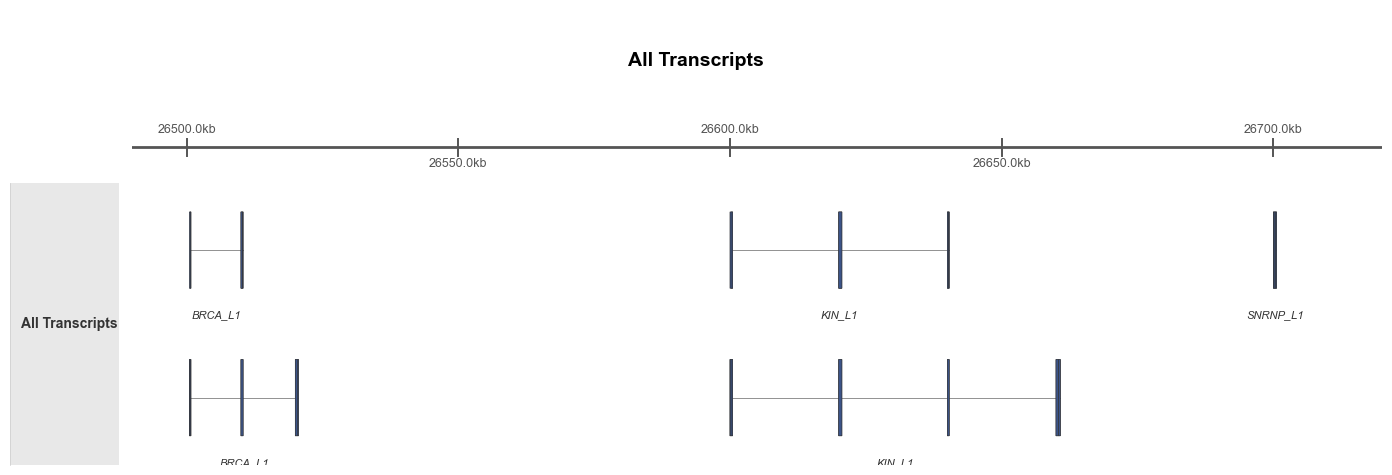

In [8]:
grtrack_all = GeneRegionTrack(gene_data, name="All Transcripts")

axes = plot_tracks(
    [gtrack, grtrack_all],
    region=gene_region,
    title="All Transcripts",
    figsize=(14, 5),
)
plt.show()


### 2b. Collapse to gene level

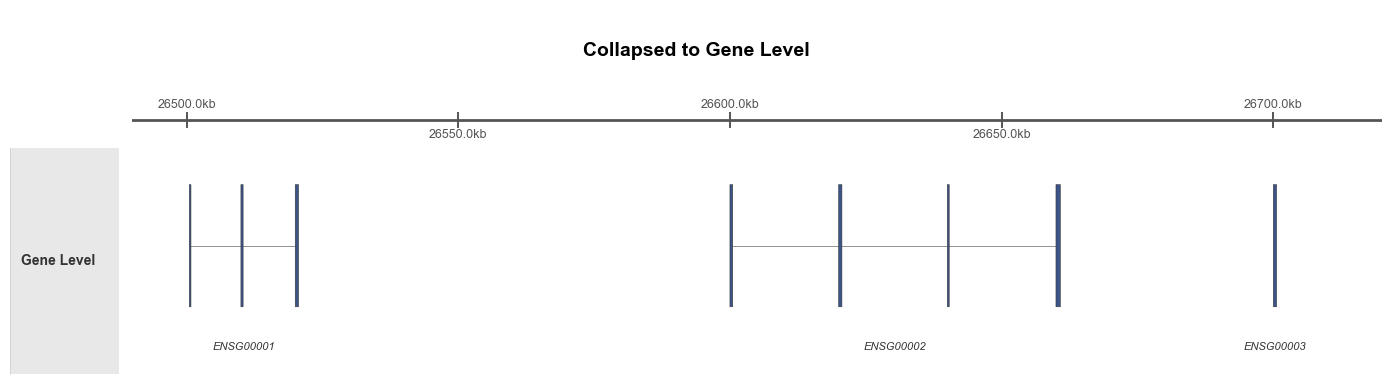

In [9]:
grtrack_gene = GeneRegionTrack(
    gene_data, name="Gene Level", collapse_transcripts="gene",
)

axes = plot_tracks(
    [gtrack, grtrack_gene],
    region=gene_region,
    title="Collapsed to Gene Level",
    figsize=(14, 4),
)
plt.show()


### 2c. Longest transcript only

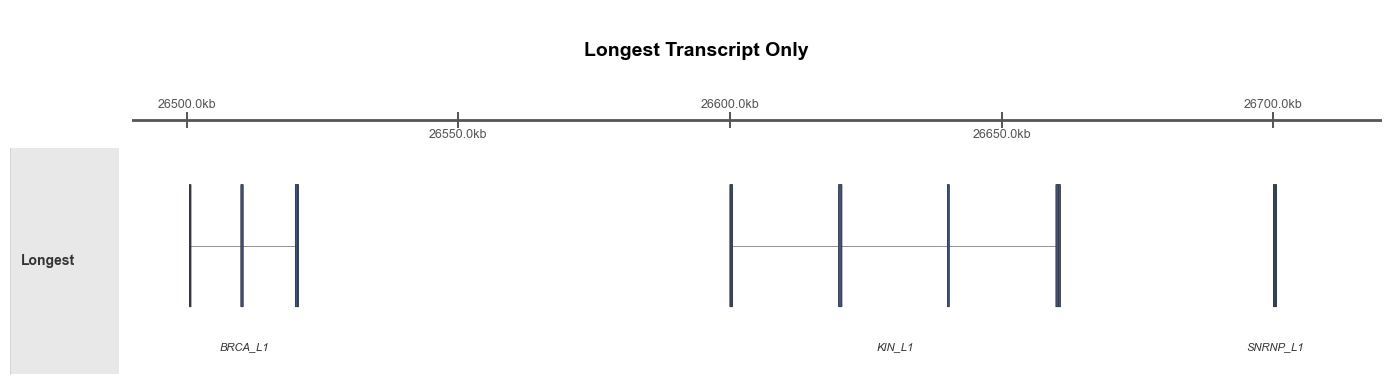

In [10]:
grtrack_long = GeneRegionTrack(
    gene_data, name="Longest", collapse_transcripts="longest",
)

axes = plot_tracks(
    [gtrack, grtrack_long],
    region=gene_region,
    title="Longest Transcript Only",
    figsize=(14, 4),
)
plt.show()


### 2d. Meta-transcript (union of all exons)

The `collapse_transcripts="meta"` mode creates a **meta-transcript** by
computing the union of all exon positions across all transcripts for each gene.

In [ ]:
grtrack_meta = GeneRegionTrack(
    gene_data, name="Meta-transcript",
    collapse_transcripts="meta",
)

axes = plot_tracks(
    [gtrack, grtrack_meta], region=gene_region,
    title="Meta-transcript (union of all exons)",
    figsize=(14, 4),
)

### 2d. Combined view — Gene models + CpG islands

Stack multiple tracks together by passing them as a list to `plot_tracks()`.
Each track gets its own panel in the figure.

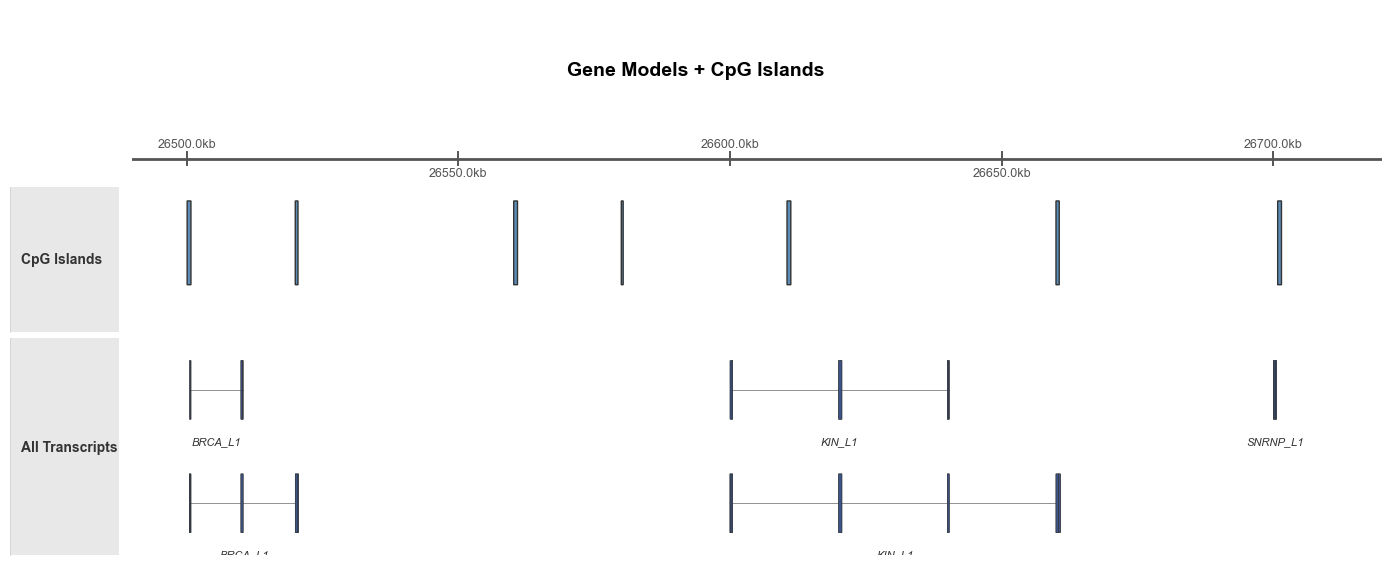

In [11]:
atrack = AnnotationTrack(cpg_data, name="CpG Islands")

axes = plot_tracks(
    [gtrack, atrack, grtrack_all],
    region=gene_region,
    title="Gene Models + CpG Islands",
    figsize=(14, 6),
)
plt.show()


---
## 3. DataTrack — Numeric Genomic Data

`DataTrack` visualizes numeric data along the genome. It supports **10 plot
types**: `line`, `histogram`, `polygon`, `points`, `mountain`, `gradient`,
`heatmap`, `boxplot`, `b` (combined line+points), `s` (stairs-post), and `S`
(stairs-pre). Additional features include `transformation`, `window` smoothing,
`aggregation`, `legend`, and `grid` display.

### Load coverage data from a bedGraph file

In [12]:
cov_data = read_bedgraph(BEDGRAPH_FILE)
print(f"Loaded {len(cov_data)} data bins")
cov_data.head()


Loaded 100 data bins


,chrom,start,end,value
0,chr7,26500000,26503000,0.5993
1,chr7,26503000,26506000,1.0717
2,chr7,26506000,26509000,1.7012
3,chr7,26509000,26512000,2.5058
4,chr7,26512000,26515000,2.9590


### 3a. Line plot

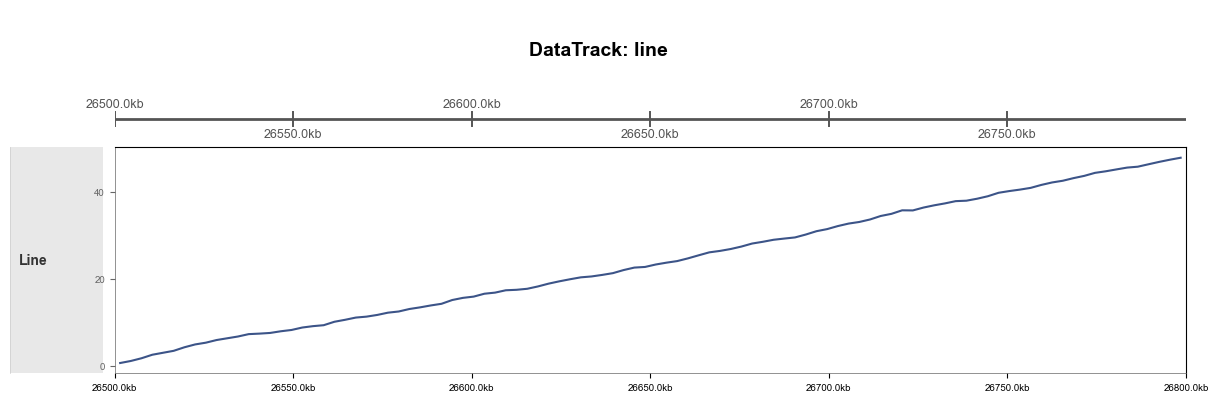

In [13]:
dtrack_line = DataTrack(cov_data, type="line", name="Line")

axes = plot_tracks(
    [gtrack, dtrack_line],
    region=region,
    title="DataTrack: line",
    figsize=(12, 4),
)
plt.show()


### 3b. Histogram

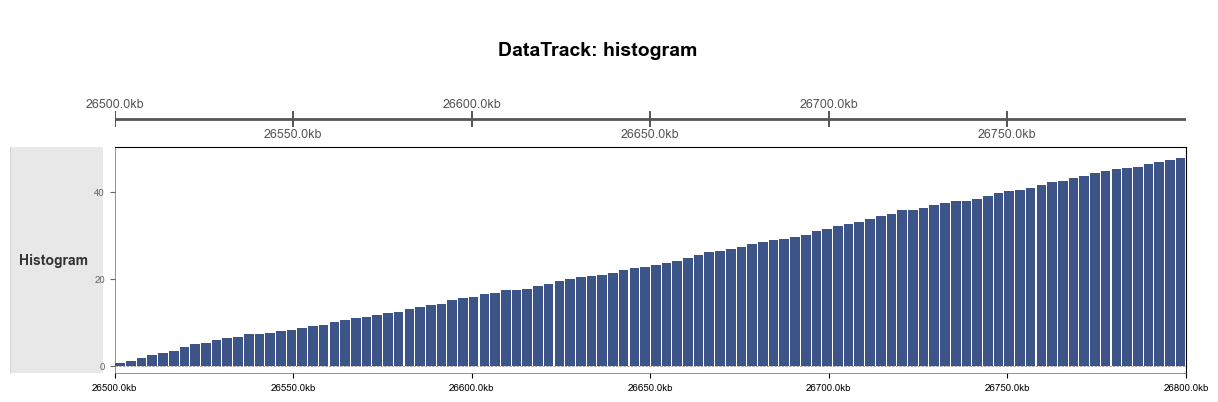

In [14]:
dtrack_hist = DataTrack(cov_data, type="histogram", name="Histogram")

axes = plot_tracks(
    [gtrack, dtrack_hist],
    region=region,
    title="DataTrack: histogram",
    figsize=(12, 4),
)
plt.show()


### 3c. Polygon (filled area)

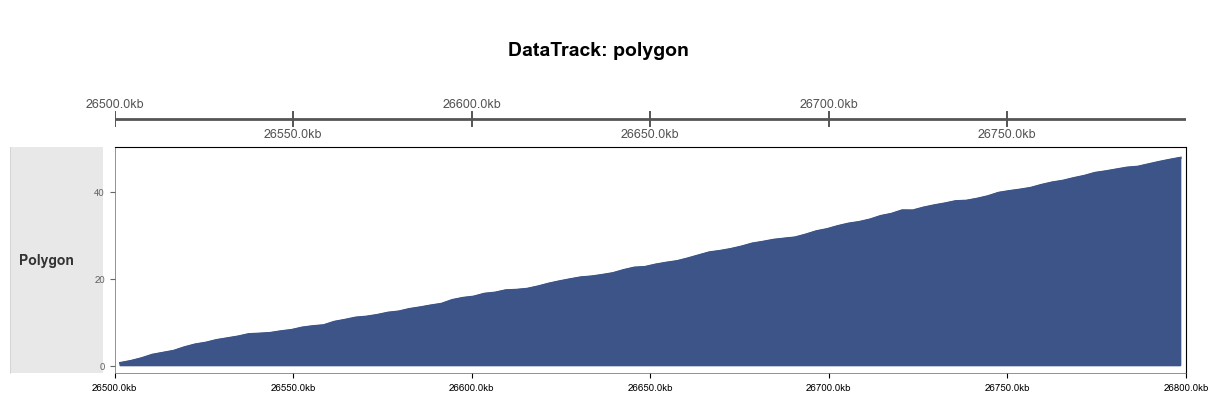

In [15]:
dtrack_poly = DataTrack(cov_data, type="polygon", name="Polygon")

axes = plot_tracks(
    [gtrack, dtrack_poly],
    region=region,
    title="DataTrack: polygon",
    figsize=(12, 4),
)
plt.show()


### 3d. Points

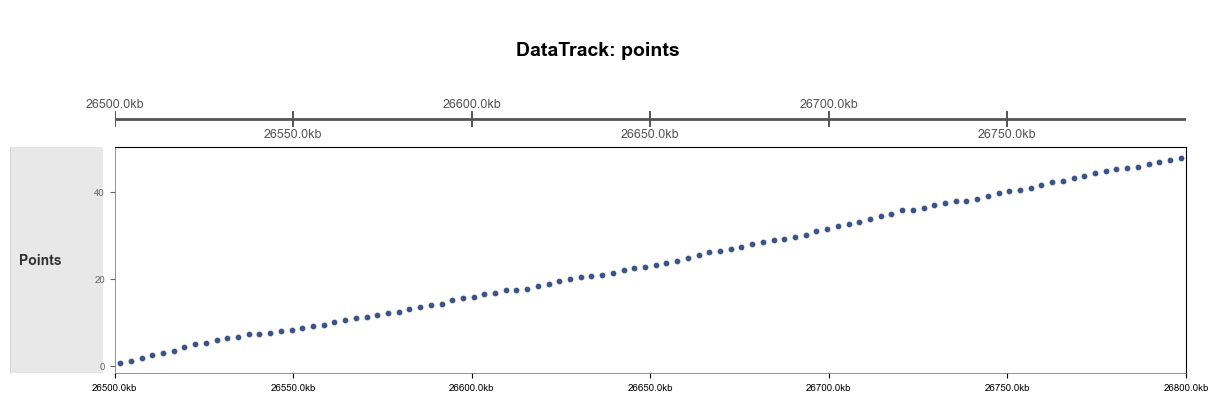

In [16]:
dtrack_pts = DataTrack(cov_data, type="points", name="Points")

axes = plot_tracks(
    [gtrack, dtrack_pts],
    region=region,
    title="DataTrack: points",
    figsize=(12, 4),
)
plt.show()


### 3e. Mountain (smoothed area)

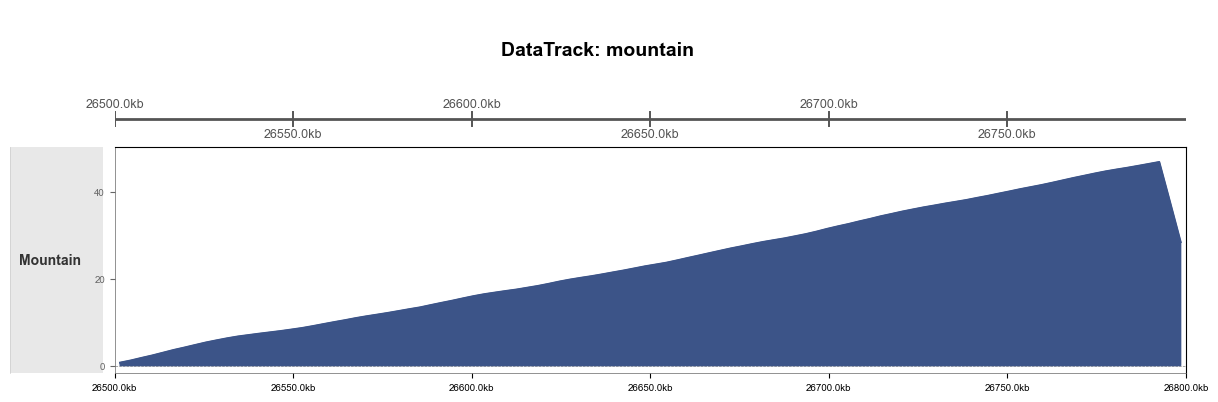

In [17]:
dtrack_mtn = DataTrack(cov_data, type="mountain", name="Mountain")

axes = plot_tracks(
    [gtrack, dtrack_mtn],
    region=region,
    title="DataTrack: mountain",
    figsize=(12, 4),
)
plt.show()


### 3f. Gradient

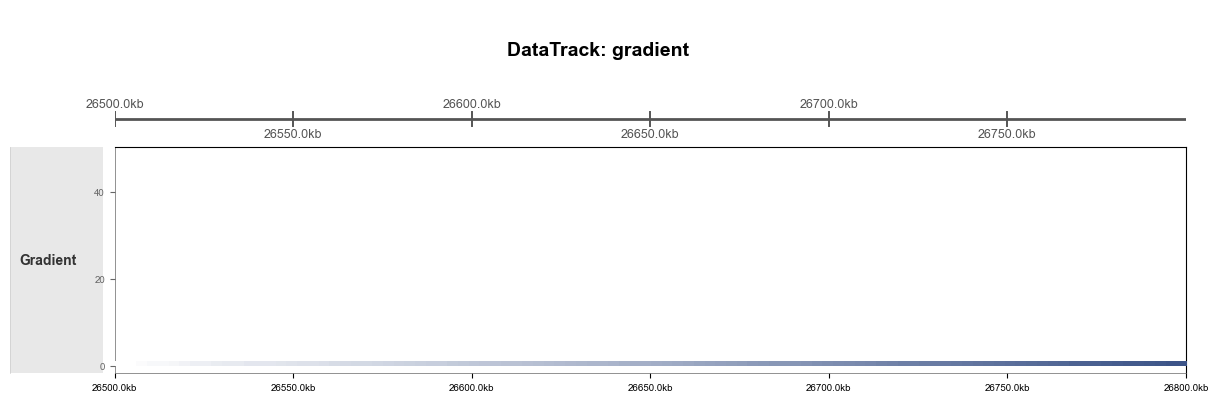

In [18]:
dtrack_grad = DataTrack(cov_data, type="gradient", name="Gradient")

axes = plot_tracks(
    [gtrack, dtrack_grad],
    region=region,
    title="DataTrack: gradient",
    figsize=(12, 4),
)
plt.show()


### 3g. Heatmap with multi-sample data

The heatmap type requires a DataFrame with **multiple numeric columns**
(one per sample). Each column becomes a row in the heatmap.

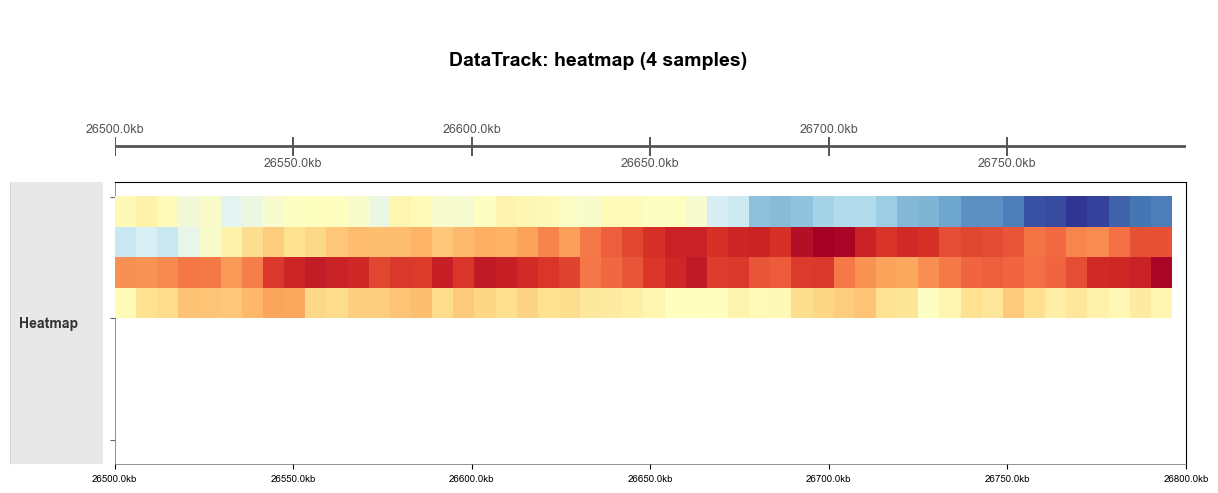

In [19]:
rng = np.random.RandomState(99)
n = 50
starts = np.linspace(26_500_000, 26_790_000, n, dtype=int)
ends = starts + 6000

heat_data = pd.DataFrame({
    "chrom": ["chr7"] * n,
    "start": starts,
    "end": ends,
    "sample_A": rng.randn(n).cumsum() / 3,
    "sample_B": rng.randn(n).cumsum() / 3 + 2,
    "sample_C": rng.randn(n).cumsum() / 3 - 1,
    "sample_D": rng.randn(n).cumsum() / 3 + 1,
})

dtrack_heat = DataTrack(heat_data, type="heatmap", name="Heatmap")

axes = plot_tracks(
    [gtrack, dtrack_heat],
    region=region,
    title="DataTrack: heatmap (4 samples)",
    figsize=(12, 5),
)
plt.show()


### 3h. Custom Y-axis limits

Use the `ylim` parameter to fix the Y-axis range, which is useful when
comparing multiple DataTracks on the same scale.

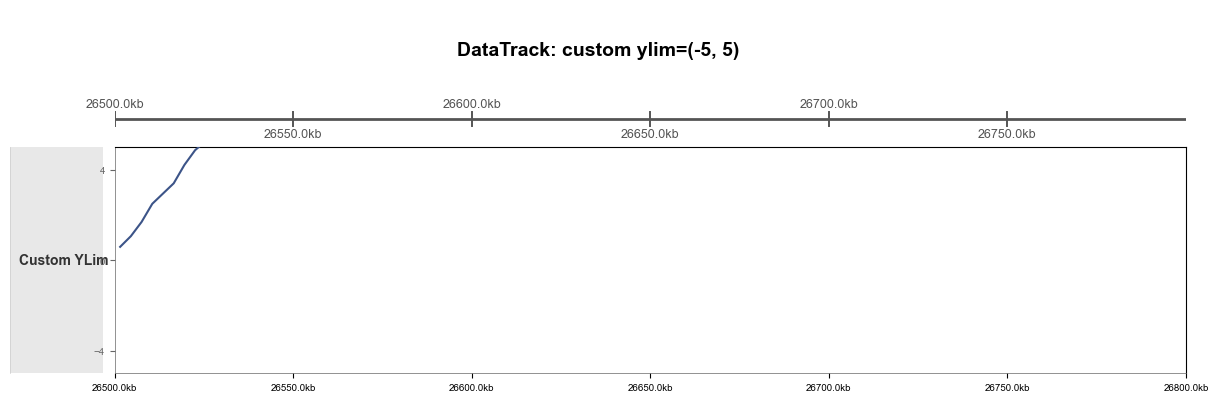

In [20]:
dtrack_ylim = DataTrack(cov_data, type="line", name="Custom YLim", ylim=(-5, 5))

axes = plot_tracks(
    [gtrack, dtrack_ylim],
    region=region,
    title="DataTrack: custom ylim=(-5, 5)",
    figsize=(12, 4),
)
plt.show()


### 3i. Combined line + points (`type="b"`)

The `"b"` type draws both a line and points.

In [ ]:
dtrack_b = DataTrack(cov_data, type="b", name="Combined")

axes = plot_tracks(
    [gtrack, dtrack_b], region=region,
    title="DataTrack: type='b' (line + points)", figsize=(12, 4),
)

### 3j. Stair steps (`type="s"` and `type="S"`)

Stair-step plots: `"s"` (post-step) or `"S"` (pre-step).

In [ ]:
dtrack_s = DataTrack(cov_data, type="s", name="Stairs-post")
axes_s = plot_tracks([gtrack, dtrack_s], region=region,
                     title="type='s' (post-step)", figsize=(12, 3))

dtrack_S = DataTrack(cov_data, type="S", name="Stairs-pre")
axes_S = plot_tracks([gtrack, dtrack_S], region=region,
                     title="type='S' (pre-step)", figsize=(12, 3))

### 3k. Transformation

Apply a callable to all values before plotting (e.g., `np.log2`).

In [ ]:
dtrack_log = DataTrack(cov_data, type="line", name="log2 Transform",
                       transformation=np.log2)

axes = plot_tracks(
    [gtrack, dtrack_log], region=region,
    title="DataTrack: transformation=np.log2", figsize=(12, 4),
)

### 3l. Windowing / Smoothing

Bin data into windows with `window` and choose aggregation.

In [ ]:
dtrack_win = DataTrack(cov_data, type="line", name="Window=50",
                       window=50, aggregation="mean")

axes = plot_tracks(
    [gtrack, dtrack_win], region=region,
    title="DataTrack: window=50, aggregation='mean'", figsize=(12, 4),
)

### 3m. Grid lines

Draw horizontal grid lines with `display_params={"grid": True}`.

In [ ]:
dtrack_grid = DataTrack(cov_data, type="line", name="With Grid",
                        display_params={"grid": True, "col_grid": "#CCCCCC"})

axes = plot_tracks(
    [gtrack, dtrack_grid], region=region,
    title="DataTrack: grid=True", figsize=(12, 4),
)

---
## 4. HighlightTrack — Cross-Track Highlighting

`HighlightTrack` wraps one or more tracks and draws semi-transparent
colored rectangles over specified genomic regions. This is useful for
marking regions of interest (e.g., peaks, variants, CNVs) across multiple
track panels simultaneously.

### 4a. Single highlight color

Create a `HighlightTrack` by specifying:
- `regions` — a DataFrame with `chrom`, `start`, `end` columns
- `track_list` — the tracks to highlight across
- `fill` — the highlight color
- `alpha` — transparency (0–1)

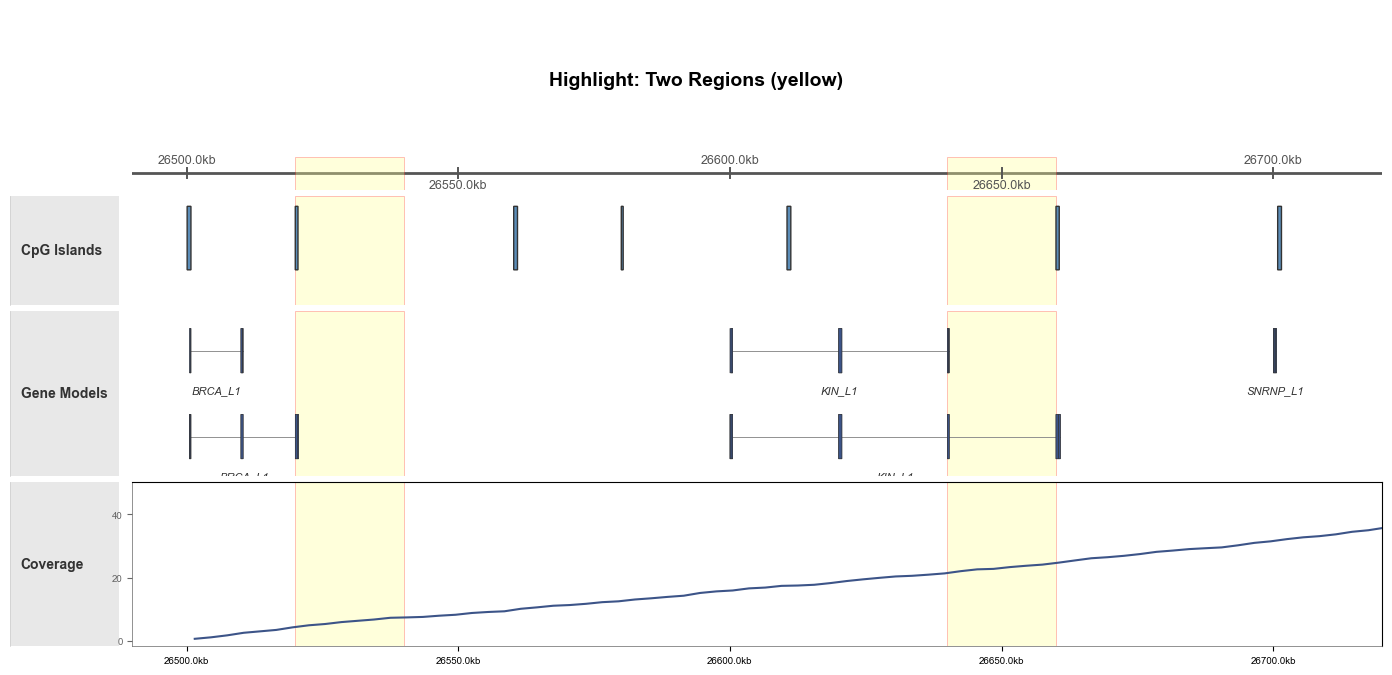

In [21]:
# Re-create tracks for this section
atrack = AnnotationTrack(cpg_data, name="CpG Islands")
grtrack = GeneRegionTrack(gene_data, name="Gene Models")
dtrack = DataTrack(cov_data, type="line", name="Coverage")

highlight_regions = pd.DataFrame({
    "chrom": ["chr7", "chr7"],
    "start": [26_520_000, 26_640_000],
    "end":   [26_540_000, 26_660_000],
})

ht = HighlightTrack(
    regions=highlight_regions,
    track_list=[atrack, grtrack, dtrack],
    fill="#FFFF99",
    alpha=0.35,
)

hl_region = GenomicInterval("chr7", 26_490_000, 26_720_000)

axes = plot_tracks(
    [gtrack, ht],
    region=hl_region,
    title="Highlight: Two Regions (yellow)",
    figsize=(14, 7),
)
plt.show()


### 4b. Multiple highlights with different colors

You can create multiple `HighlightTrack` objects with different colors
and target different sets of tracks. Place them in the track list
alongside regular tracks.

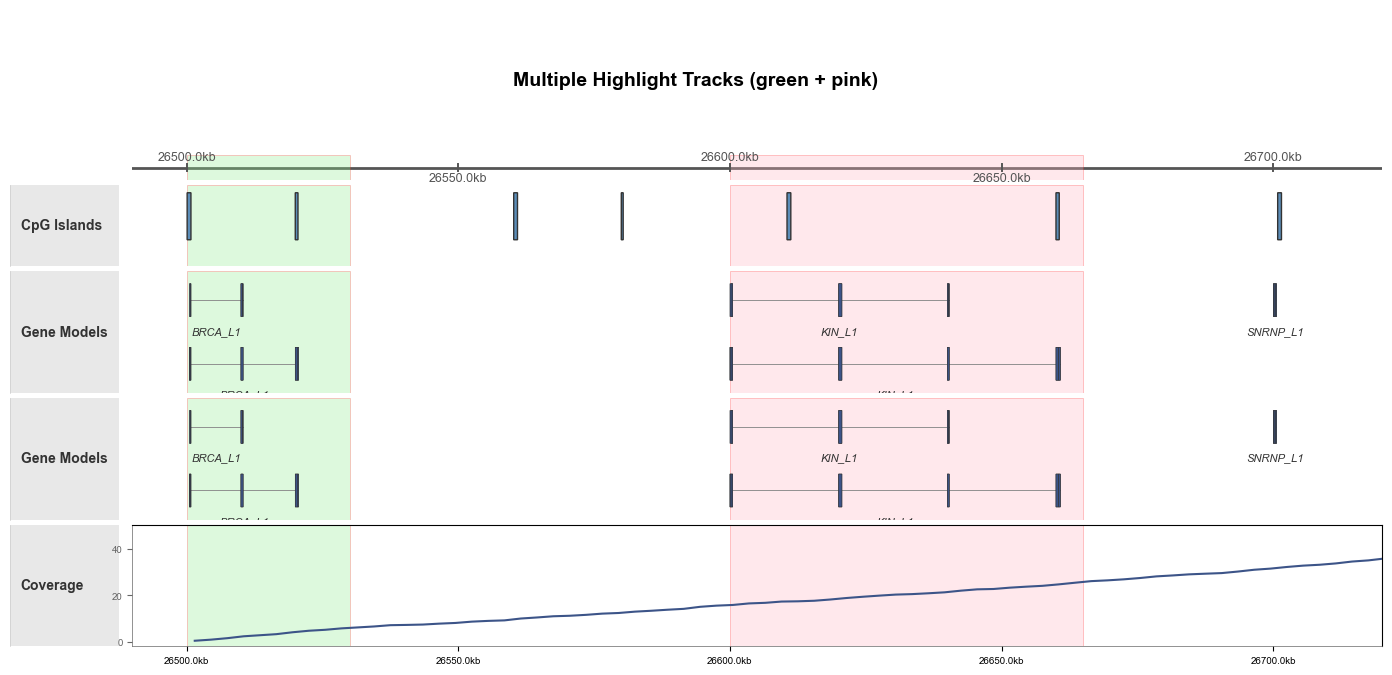

In [22]:
ht_green = HighlightTrack(
    regions=pd.DataFrame({
        "chrom": ["chr7"], "start": [26_500_000], "end": [26_530_000],
    }),
    track_list=[atrack, grtrack],
    fill="#90EE90", alpha=0.3,
)

ht_red = HighlightTrack(
    regions=pd.DataFrame({
        "chrom": ["chr7"], "start": [26_600_000], "end": [26_665_000],
    }),
    track_list=[dtrack],
    fill="#FFB6C1", alpha=0.3,
)

axes = plot_tracks(
    [gtrack, ht_green, grtrack, ht_red],
    region=hl_region,
    title="Multiple Highlight Tracks (green + pink)",
    figsize=(14, 7),
)
plt.show()


### 4c. Per-region colors

Pass a **list** of colors to `fill` and `col` for per-region coloring.

In [ ]:
ht_colors = HighlightTrack(
    regions=pd.DataFrame({
        "chrom": ["chr7", "chr7", "chr7"],
        "start": [26_500_000, 26_560_000, 26_640_000],
        "end":   [26_530_000, 26_590_000, 26_670_000],
    }),
    track_list=[atrack, grtrack],
    fill=["#FF9999", "#99FF99", "#9999FF"],
    col=["#CC0000", "#00CC00", "#0000CC"],
    alpha=0.3,
)

axes = plot_tracks(
    [gtrack, ht_colors], region=region,
    title="Per-Region Highlight Colors", figsize=(14, 7),
)

---
## 5. OverlayTrack — Overlay Multiple Tracks

`OverlayTrack` draws multiple tracks on the **same axes**, useful for
comparing signals from different DataTracks.

In [ ]:
rng = np.random.RandomState(42)
n = len(cov_data)
starts = cov_data["start"].values
ends = cov_data["end"].values

data_a = pd.DataFrame({
    "chrom": ["chr7"] * n, "start": starts, "end": ends,
    "signal_A": rng.randn(n).cumsum() / 2,
})
data_b = pd.DataFrame({
    "chrom": ["chr7"] * n, "start": starts, "end": ends,
    "signal_B": rng.randn(n).cumsum() / 2 + 3,
})

dtrack_a = DataTrack(data_a, type="line", name="Sample A",
                     display_params={"col": "#3C5488"})
dtrack_b = DataTrack(data_b, type="line", name="Sample B",
                     display_params={"col": "#E64B35", "alpha": 0.7})

otrack = OverlayTrack([dtrack_a, dtrack_b], name="Overlay")

axes = plot_tracks(
    [gtrack, otrack], region=region,
    title="OverlayTrack: Compare Two Signals", figsize=(14, 5),
)

---
## 6. Advanced plot_tracks Options

### Direction indicators

Add 5'→3' or 3'→5' direction arrows with `add53` / `add35`.

In [ ]:
gtrack_dir = GenomeAxisTrack(little_ticks=True, add53=True)

axes = plot_tracks(
    [gtrack_dir, atrack], region=region,
    title="Axis with 5'->3' Direction Arrow", figsize=(12, 4),
)

### Hide title panels

Set `show_title=False` for a compact layout.

In [ ]:
dtrack = DataTrack(cov_data, type="histogram", name="Coverage",
                   display_params={"fill": "#4DBBD5", "col": "#4DBBD5"})

axes = plot_tracks(
    [GenomeAxisTrack(), atrack, dtrack],
    region=region, show_title=False,
    title="Compact Layout (no title panels)", figsize=(14, 5),
)

### Reverse strand

Flip the x-axis so 3' is on the left with `reverse_strand=True`.

In [ ]:
axes = plot_tracks(
    [GenomeAxisTrack(add35=True), atrack, dtrack],
    region=region, reverse_strand=True,
    title="Reverse Strand (3' on left)", figsize=(14, 5),
)

---
## 5. Comprehensive Example — All Track Types Combined

This final example combines every track type into a single multi-panel
figure with custom styling, sizes, and region extension — suitable for
a publication figure.

### Load all data sources

In [23]:
cpg_data = read_bed(BED_FILE)
gene_data = read_gff(GTF_FILE)
cov_data = read_bedgraph(BEDGRAPH_FILE)
ann_data = read_bed(ANN_FILE)


### Create styled tracks

In [24]:
region = GenomicInterval("chr7", 26_490_000, 26_720_000)

gtrack = GenomeAxisTrack(little_ticks=True)

atrack_cpg = AnnotationTrack(
    cpg_data, name="CpG Islands",
    display_params={"fill": "#3C5488"},
)

atrack_ann = AnnotationTrack(
    ann_data, name="Regulatory",
    shape="ellipse",
    display_params={"fill": "#E64B35"},
)

grtrack = GeneRegionTrack(
    gene_data, name="Gene Models",
    collapse_transcripts="longest",
)

dtrack = DataTrack(
    cov_data, type="histogram", name="Coverage",
    display_params={"fill": "#4DBBD5", "col": "#4DBBD5"},
)


### Add highlight regions

In [25]:
ht = HighlightTrack(
    regions=pd.DataFrame({
        "chrom": ["chr7", "chr7"],
        "start": [26_505_000, 26_600_000],
        "end":   [26_535_000, 26_665_000],
    }),
    track_list=[atrack_cpg, atrack_ann, grtrack, dtrack],
    fill="#FFF3BF",
    alpha=0.3,
)


### Render the final figure

- `sizes` controls relative heights of each track panel
- `extend_left` / `extend_right` add padding to the x-axis
- `figsize` sets the overall figure dimensions

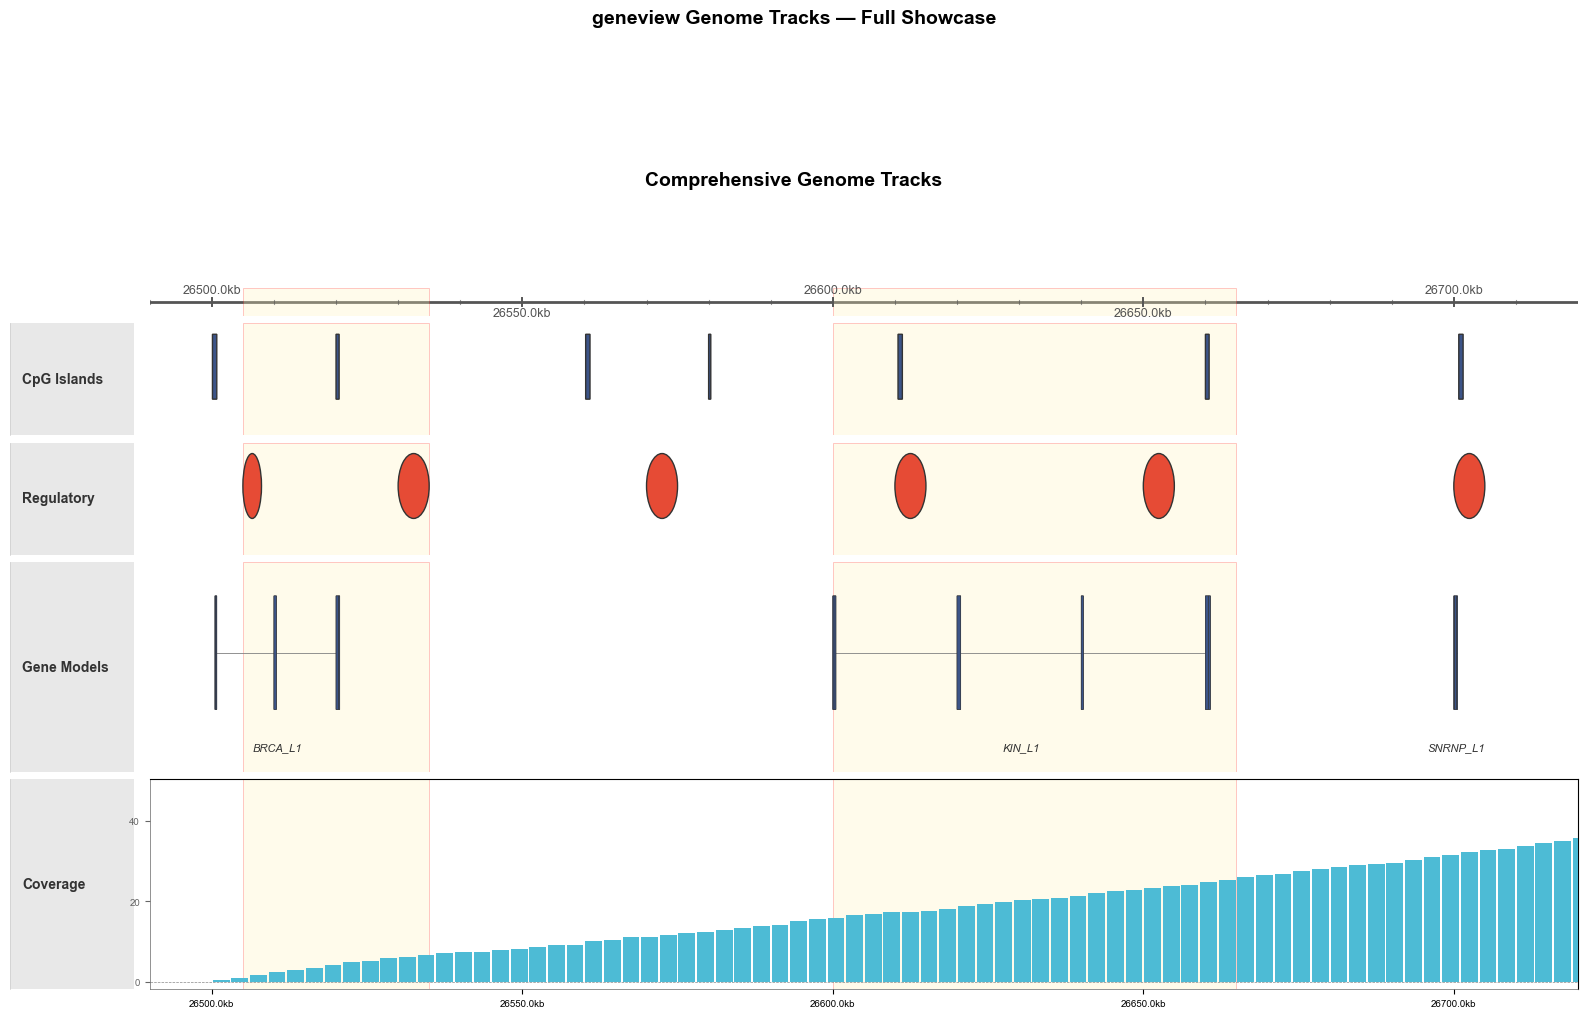

In [26]:
axes = plot_tracks(
    [gtrack, ht],
    region=region,
    sizes=[0.2, 0.8, 0.8, 1.5, 1.5],
    title="Comprehensive Genome Tracks",
    figsize=(16, 10),
    extend_left=0.05,
    extend_right=0.05,
)

fig = axes[0].figure
plt.suptitle(
    "geneview Genome Tracks — Full Showcase",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.show()


## Summary

You have now learned how to:

1. **Create basic tracks** — `GenomeAxisTrack` for coordinates, `AnnotationTrack` for features
2. **Visualize gene models** — `GeneRegionTrack` with collapse modes (gene, longest, shortest, meta)
3. **Plot numeric data** — `DataTrack` with 10 plot types, transformation, windowing, aggregation, grid
4. **Highlight regions** — `HighlightTrack` with per-region colors and targeted panels
5. **Overlay signals** — `OverlayTrack` for comparing multiple DataTracks on the same axes
6. **Customize layout** — direction indicators, reverse strand, show/hide title panels, fractional extend
7. **Combine everything** — comprehensive multi-panel figures with `plot_tracks()`

For more details, see the [genome_tracks_guide](../genome_tracks_guide.md) and
the example scripts in `examples/scripts/`.